# 03 — Train / Test Split & XGBoost Training

**Input:** `datasets/ebay_processed.parquet`  
**Outputs:**
- `packages/ml/pricing_model.pkl` — model bundle (model + encoders + feature names)
- `datasets/ebay_test_set.parquet` — held-out test features + labels for notebook 04

## Strategy

Split: **70% train / 15% val / 15% test**

- Val set is used for XGBoost early stopping — keeps test set truly unseen.
- Test set is written to disk and loaded by `04_kaggle_evaluate.ipynb`.
- Target is `log_price` (log1p of USD); predictions are inverse-transformed with `expm1` before serving.

Categorical encoding: simple integer mapping (dict-based).  
Unknown categories at inference time map to `-1`; XGBoost treats these like any other numeric value.

In [1]:
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xgboost as xgb
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

PROCESSED_PATH = Path('../datasets/ebay_processed.parquet')
TEST_SET_PATH  = Path('../datasets/ebay_test_set.parquet')
MODEL_PATH     = Path('../packages/ml/pricing_model.pkl')

RANDOM_STATE = 42

---
## 1. Load Processed Data

In [2]:
df = pd.read_parquet(PROCESSED_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.dtypes

Loaded: 16,901 rows × 15 columns


Uniq Id                    str
Title                      str
price_usd              float64
log_price              float64
is_used                  int64
manufacturer_clean         str
internal_memory_gb     float64
screen_size_in         float64
color_clean                str
seller_rating_pct      float64
seller_review_count    float64
log_seller_reviews     float64
title_len_words        float64
has_model_num            int64
has_upc                  int64
dtype: object

---
## 2. Define Features & Target

In [3]:
# features available both in training data and at inference time from the DB Item record
NUMERIC_FEATURES = [
    'is_used',            # 0/1 flag derived from title or condition enum
    'internal_memory_gb', # -1 sentinel when unknown
    'screen_size_in',     # -1 sentinel when unknown
    'seller_rating_pct',  # -1 sentinel when unknown
    'log_seller_reviews', # -1 sentinel when unknown
    'title_len_words',    # word count of listing title
    'has_model_num',      # 1 if a model number is present
    'has_upc',            # 1 if a UPC barcode is present
]

CATEGORICAL_FEATURES = [
    'manufacturer_clean', # normalised brand name
    'color_clean',        # normalised colour string
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = 'log_price'

print('Feature count:', len(ALL_FEATURES))
print('Features:', ALL_FEATURES)

Feature count: 10
Features: ['is_used', 'internal_memory_gb', 'screen_size_in', 'seller_rating_pct', 'log_seller_reviews', 'title_len_words', 'has_model_num', 'has_upc', 'manufacturer_clean', 'color_clean']


---
## 3. Encode Categorical Features

Map each categorical to an integer index using a dict built on the full dataset.  
The mapping is saved in the model bundle so the agent can apply the same transform at inference.

In [4]:
# build mapping: category string → integer index
# 'unknown' is always index 0 so unseen categories at inference map cleanly
encoders: dict[str, dict[str, int]] = {}

for col in CATEGORICAL_FEATURES:
    unique_vals = sorted(df[col].dropna().unique().tolist())
    # reserve 0 for 'unknown' / unseen categories
    mapping = {'unknown': 0}
    mapping.update({v: i + 1 for i, v in enumerate(unique_vals) if v != 'unknown'})
    encoders[col] = mapping
    df[f'{col}_enc'] = df[col].map(mapping).fillna(0).astype(int)
    print(f'{col}: {len(mapping)} unique values')

# replace original categorical columns with encoded versions
ENCODED_FEATURES = NUMERIC_FEATURES + [f'{c}_enc' for c in CATEGORICAL_FEATURES]
print('\nFinal encoded feature list:', ENCODED_FEATURES)

manufacturer_clean: 13038 unique values
color_clean: 200 unique values

Final encoded feature list: ['is_used', 'internal_memory_gb', 'screen_size_in', 'seller_rating_pct', 'log_seller_reviews', 'title_len_words', 'has_model_num', 'has_upc', 'manufacturer_clean_enc', 'color_clean_enc']


---
## 4. Train / Val / Test Split

In [5]:
X = df[ENCODED_FEATURES].values.astype(float)
y = df[TARGET].values

# replace any inf/-inf produced by log transforms on extreme values with NaN
# XGBoost treats NaN as missing and handles it via tree splits
inf_count = np.isinf(X).sum()
if inf_count > 0:
    print(f'Replacing {inf_count} inf values with NaN')
    X[np.isinf(X)] = np.nan

# first cut: 85% train+val, 15% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE
)

# second cut: split remaining into 70% train, 15% val (≈82/18 of trainval)
val_ratio = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_ratio, random_state=RANDOM_STATE
)

print(f'Train: {len(X_train):,} rows')
print(f'Val:   {len(X_val):,} rows')
print(f'Test:  {len(X_test):,} rows')

Replacing 3 inf values with NaN
Train: 11,830 rows
Val:   2,535 rows
Test:  2,536 rows


---
## 5. Train XGBoost Regressor

In [6]:
model = xgb.XGBRegressor(
    n_estimators=1000,      # large budget; early stopping will find the right number
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,          # row subsampling per tree (reduces overfitting)
    colsample_bytree=0.8,   # feature subsampling per tree
    reg_alpha=0.1,          # L1 regularisation
    reg_lambda=1.0,         # L2 regularisation
    objective='reg:squarederror',
    eval_metric='rmse',
    early_stopping_rounds=30,  # stop if val RMSE doesn't improve for 30 rounds
    random_state=RANDOM_STATE,
    verbosity=1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,  # print every 50 rounds
)

print(f'\nBest iteration: {model.best_iteration}')

[0]	validation_0-rmse:1.27075
[50]	validation_0-rmse:1.05122
[100]	validation_0-rmse:1.02260
[150]	validation_0-rmse:1.00990
[200]	validation_0-rmse:1.00332
[250]	validation_0-rmse:0.99901
[300]	validation_0-rmse:0.99776
[310]	validation_0-rmse:0.99750

Best iteration: 280


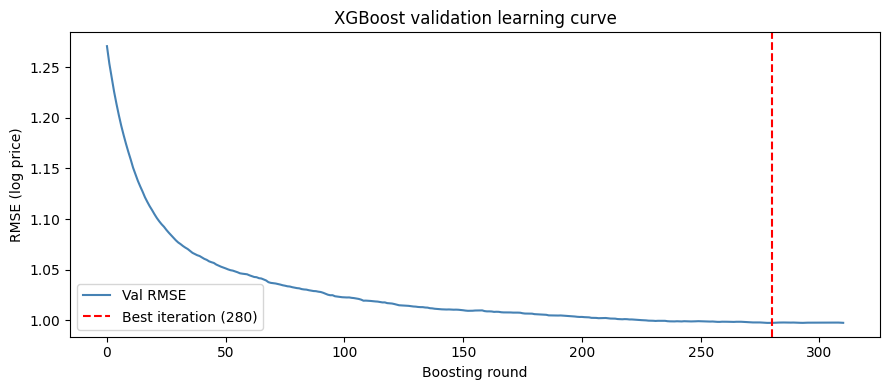

In [7]:
import matplotlib.pyplot as plt

# training curve — shows when early stopping kicked in
results = model.evals_result()
train_rmse = results['validation_0']['rmse']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_rmse, label='Val RMSE', color='steelblue')
ax.axvline(model.best_iteration, color='red', linestyle='--',
           label=f'Best iteration ({model.best_iteration})')
ax.set_xlabel('Boosting round')
ax.set_ylabel('RMSE (log price)')
ax.set_title('XGBoost validation learning curve')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# quick in-sample and val metrics — full evaluation is in notebook 04
for split_name, X_s, y_s in [('Train', X_train, y_train), ('Val', X_val, y_val)]:
    preds = model.predict(X_s)
    rmse = mean_squared_error(y_s, preds) ** 0.5
    mae  = mean_absolute_error(y_s, preds)
    r2   = r2_score(y_s, preds)
    print(f'{split_name:6s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')

Train   RMSE=0.8770  MAE=0.6793  R²=0.5498
Val     RMSE=0.9974  MAE=0.7732  R²=0.4015


---
## 6. Save Model Bundle & Test Set

In [9]:
# model bundle — everything the agent needs to reproduce the exact same transform
bundle = {
    'model': model,
    'encoders': encoders,              # dict[col_name → dict[str → int]]
    'feature_names': ENCODED_FEATURES, # ordered list used for np.array columns
    'categorical_features': CATEGORICAL_FEATURES,
    'numeric_features': NUMERIC_FEATURES,
}

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(bundle, f)

size_kb = MODEL_PATH.stat().st_size / 1024
print(f'Model saved → {MODEL_PATH}  ({size_kb:.1f} KB)')

Model saved → ../packages/ml/pricing_model.pkl  (2137.5 KB)


In [10]:
# save test set (features + true log_price + true price_usd) for notebook 04
# reconstruct original test indices to grab price_usd alongside
test_df = pd.DataFrame(X_test, columns=ENCODED_FEATURES)
test_df['log_price_true'] = y_test
# inverse-transform to USD for human-readable evaluation
test_df['price_usd_true'] = np.expm1(y_test)

test_df.to_parquet(TEST_SET_PATH, index=False)
print(f'Test set saved → {TEST_SET_PATH}  ({len(test_df):,} rows)')

Test set saved → ../datasets/ebay_test_set.parquet  (2,536 rows)


---
## Summary

| | Rows |
|---|---|
| Train | ~11,800 |
| Val | ~2,500 |
| Test | ~2,500 |

The model bundle at `packages/ml/pricing_model.pkl` contains the XGBoost model, the categorical encoders, and the feature name list.  
**Next:** open `04_kaggle_evaluate.ipynb` for held-out test evaluation and feature importance.